# Analyse des erreurs NER — où Opener se trompe le plus

Identifie les **confusions systématiques** (paires gold → pred les plus fréquentes) et affiche des spans concrets avec contexte pour comprendre la cause et proposer des corrections : enrichir les anchor words, fusionner des labels ambigus, etc.

## Pipeline

Nomic v1.5 @768 (figé) → **Logistic Regression** (classifieur discriminatif, +25 % AMI vs GMM d'après le classifier sweep) → analyse des erreurs.

Le notebook tourne dataset par dataset (modifiable dans la cellule de paramètres). L'embedding est la seule étape coûteuse (GPU, quelques minutes), les classifieurs et l'analyse sont en CPU instantané.

In [3]:
# === Paramètres (modifiables) ===
DATASET = 'wnut17'   # 'wnut17' | 'fabner' | 'mit_restaurant' | 'crossner' | 'bionlp2004' | 'conll2003'
MAX_TRAIN = 2000
MAX_EVAL = 1000
N_TOP_ERRORS = 8                # top N paires (gold, pred) à inspecter
N_EXAMPLES_PER_ERROR = 5        # nombre de spans d'exemple par paire
CLASSIFIER = 'logreg'           # 'logreg' (probas → confidences) | 'linear_svm' | 'gmm_diag'
CONTEXT_CHARS = 60              # chars de contexte à gauche/droite du span dans l'affichage

In [4]:
import os, sys
# Lancement depuis tests/ → ajoute la racine au PYTHONPATH pour importer src.*
_root = os.path.abspath('..')
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_mutual_info_score, accuracy_score, confusion_matrix

from src.data.owner_datasets import load_owner_dataset
from src.models.embedder import Embedder

In [5]:
# === Chargement embedder + dataset ===
print('Chargement embedder Nomic v1.5 @768...')
embedder = Embedder(model_name='nomic-ai/nomic-embed-text-v1.5', truncate_dim=None,
                    encoding_mode='span_in_context', task_prefix='classification: ')

print(f'Chargement dataset {DATASET}...')
try:
    train = load_owner_dataset(DATASET, split='train', max_sentences=MAX_TRAIN)
except Exception:
    train = load_owner_dataset(DATASET, split='validation', max_sentences=MAX_TRAIN)
try:
    test = load_owner_dataset(DATASET, split='test', max_sentences=MAX_EVAL)
except Exception:
    test = load_owner_dataset(DATASET, split='validation', max_sentences=MAX_EVAL)
print(f'  train {len(train)} phrases · test {len(test)} phrases')

Chargement embedder Nomic v1.5 @768...
Chargement dataset wnut17...
  train 1228 phrases · test 689 phrases


In [6]:
# === Embedding des spans gold + meta (texte/contexte) ===
def embed_with_meta(corpus, batch_size=64):
    X_parts, y, meta = [], [], []
    for text, spans in corpus:
        if not spans: continue
        for cs in range(0, len(spans), batch_size):
            chunk = spans[cs:cs+batch_size]
            emb = embedder.embed_entities([text[s:e] for (s,e,_) in chunk],
                                          full_text=text,
                                          spans=[(s,e) for (s,e,_) in chunk])
            X_parts.append(emb)
            for (s,e,lbl) in chunk:
                y.append(lbl)
                meta.append({'text': text, 'span_text': text[s:e],
                              'start': s, 'end': e, 'gold': lbl})
    return np.vstack(X_parts), np.array(y), meta

print('Embedding train...')
X_tr, y_tr, meta_tr = embed_with_meta(train)
print(f'  X_tr {X_tr.shape}')
print('Embedding test...')
X_te, y_te, meta_te = embed_with_meta(test)
print(f'  X_te {X_te.shape}')

Embedding train...


<All keys matched successfully>


  X_tr (1975, 768)
Embedding test...
  X_te (1079, 768)


In [8]:
# === Fit + predict ===
proba = None
if CLASSIFIER == 'logreg':
    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    proba = clf.predict_proba(X_te)
    classes = list(clf.classes_)
elif CLASSIFIER == 'linear_svm':
    clf = LinearSVC(C=1.0)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    classes = list(clf.classes_)
elif CLASSIFIER == 'gmm_diag':
    classes = sorted(set(y_tr))
    gmms = {}
    for c in classes:
        Xc = X_tr[y_tr == c]
        ncomp = max(1, min(2, len(Xc)))
        g = GaussianMixture(n_components=ncomp, covariance_type='diag',
                            reg_covar=1e-4, random_state=42, max_iter=200)
        g.fit(Xc); gmms[c] = g
    scores = np.column_stack([gmms[c].score_samples(X_te) for c in classes])
    y_pred = np.array([classes[i] for i in scores.argmax(axis=1)])
    # softmax sur log-lik pour faire un proxy de proba
    s = scores - scores.max(axis=1, keepdims=True)
    proba = np.exp(s); proba /= proba.sum(axis=1, keepdims=True)
else:
    raise ValueError(f'Classifieur inconnu: {CLASSIFIER!r}')

ami = adjusted_mutual_info_score(y_te, y_pred)
acc = accuracy_score(y_te, y_pred)
print(f'Classifieur {CLASSIFIER}  ·  AMI = {ami:.4f}  ·  Accuracy = {acc:.4f}')

Classifieur logreg  ·  AMI = 0.1729  ·  Accuracy = 0.5338


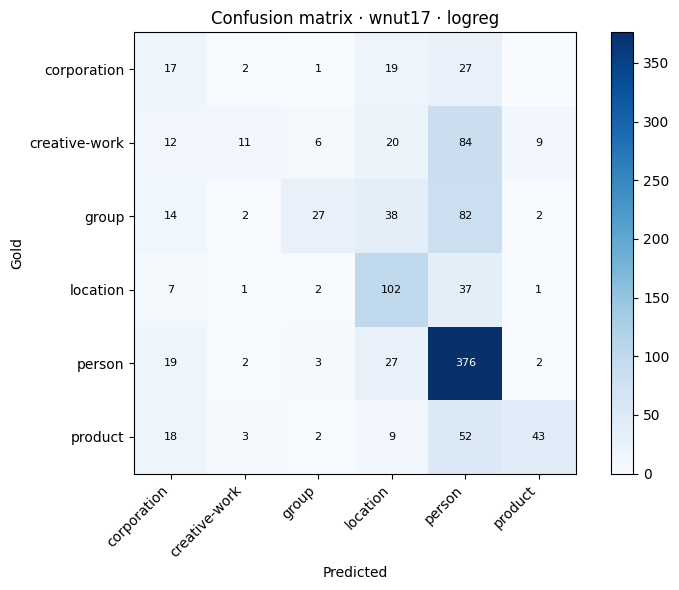

In [9]:
# === Matrice de confusion (vue d'ensemble) ===
labels_sorted = sorted(set(y_te) | set(y_pred))
cm = confusion_matrix(y_te, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(max(8, 0.7*len(labels_sorted)), max(6, 0.5*len(labels_sorted))))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels_sorted))); ax.set_yticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha='right')
ax.set_yticklabels(labels_sorted)
ax.set_xlabel('Predicted'); ax.set_ylabel('Gold')
ax.set_title(f'Confusion matrix · {DATASET} · {CLASSIFIER}')
max_v = cm.max() if cm.size else 1
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        if cm[i,j]:
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=8,
                    color='white' if cm[i,j] > max_v/2 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

In [10]:
# === Top N paires d'erreurs (gold → pred) par fréquence ===
error_pairs = Counter()
error_indices = {}
for i, (g, p) in enumerate(zip(y_te, y_pred)):
    if g != p:
        error_pairs[(g, p)] += 1
        error_indices.setdefault((g, p), []).append(i)

n_errors_total = sum(error_pairs.values())
n_test = len(y_te)
top = error_pairs.most_common(N_TOP_ERRORS)

rows = []
for (g, p), c in top:
    pct_total = 100 * c / n_test
    pct_errors = 100 * c / n_errors_total if n_errors_total else 0
    rows.append({'gold': g, 'pred': p, 'count': c,
                 '% du test': round(pct_total, 1),
                 '% des erreurs': round(pct_errors, 1)})
df_top = pd.DataFrame(rows)
print(f'Total erreurs : {n_errors_total} / {n_test} ({100*n_errors_total/n_test:.1f} %)')
print(f'Top {len(top)} confusions :')
df_top

Total erreurs : 503 / 1079 (46.6 %)
Top 8 confusions :


,gold,pred,count,% du test,% des erreurs
0,creative-work,person,84,7.8,16.7
1,group,person,82,7.6,16.3
2,product,person,52,4.8,10.3
3,group,location,38,3.5,7.6
4,location,person,37,3.4,7.4
5,person,location,27,2.5,5.4
6,corporation,person,27,2.5,5.4
7,creative-work,location,20,1.9,4.0


In [11]:
# === Pour chaque top paire, montrer N spans d'exemple avec contexte + proba ===
def pidx(label):
    return classes.index(label) if label in classes else None

for (gold, pred), count in top:
    print('\n' + '='*78)
    print(f'GOLD = {gold!r}   →   PRED = {pred!r}    ({count} cas)')
    print('='*78)
    for idx in error_indices[(gold, pred)][:N_EXAMPLES_PER_ERROR]:
        m = meta_te[idx]
        s, e = m['start'], m['end']
        left = m['text'][max(0, s-CONTEXT_CHARS):s]
        right = m['text'][e:min(len(m['text']), e+CONTEXT_CHARS)]
        print(f"\n  span : « {m['span_text']} »")
        print(f"  ctx  : ...{left}[[{m['span_text']}]]{right}...")
        if proba is not None:
            ig, ip = pidx(gold), pidx(pred)
            if ig is not None and ip is not None:
                print(f"  proba(gold={gold})={proba[idx,ig]:.3f}  vs  proba(pred={pred})={proba[idx,ip]:.3f}")


GOLD = 'creative-work'   →   PRED = 'person'    (84 cas)

  span : « The X-Files »
  ctx  : ...She ' s been making me question my sexuality since [[The X-Files]] started ....
  proba(gold=creative-work)=0.172  vs  proba(pred=person)=0.604

  span : « Digeridoo »
  ctx  : ...Ah , the ol ' Adelaide [ [[Digeridoo]] !...
  proba(gold=creative-work)=0.089  vs  proba(pred=person)=0.513

  span : « Demolition Man »
  ctx  : ...Well looks like [[Demolition Man]] has come true ....
  proba(gold=creative-work)=0.114  vs  proba(pred=person)=0.581

  span : « FIFA XI »
  ctx  : ...Also , check the [[FIFA XI]] thread where a lot of people were shitting on him when he a...
  proba(gold=creative-work)=0.019  vs  proba(pred=person)=0.734

  span : « ess jay dubs »
  ctx  : ...e except the OP ( who seems to [ shit their pants about the [[ess jay dubs]] , just like you ] ( https://www.reddit.com/r/newzealand/com...
  proba(gold=creative-work)=0.020  vs  proba(pred=person)=0.766

GOLD = 'group'   →   PR

In [12]:
# === Par label gold : précision/rappel + principaux faux positifs/négatifs ===
rows = []
for lbl in labels_sorted:
    tp = int(((y_te == lbl) & (y_pred == lbl)).sum())
    fn = int(((y_te == lbl) & (y_pred != lbl)).sum())
    fp = int(((y_te != lbl) & (y_pred == lbl)).sum())
    support = tp + fn
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec  = tp / support if support else 0
    f1   = 2*prec*rec / (prec + rec) if (prec + rec) else 0
    # où ce label va quand il est mal classé
    misdir = Counter(y_pred[(y_te == lbl) & (y_pred != lbl)]).most_common(3)
    misdir_str = ', '.join(f'{p}({c})' for p, c in misdir) if misdir else '—'
    rows.append({'label': lbl, 'support': support, 'TP': tp, 'FP': fp, 'FN': fn,
                 'precision': round(prec, 3), 'recall': round(rec, 3), 'F1': round(f1, 3),
                 'top mispred → ': misdir_str})
df_per = pd.DataFrame(rows).sort_values('F1')
df_per

,label,support,TP,FP,FN,precision,recall,F1,top mispred →
1,creative-work,142,11,10,131,0.524,0.077,0.135,"person(84), location(20), corporation(12)"
0,corporation,66,17,70,49,0.195,0.258,0.222,"person(27), location(19), creative-work(2)"
2,group,165,27,14,138,0.659,0.164,0.262,"person(82), location(38), corporation(14)"
5,product,127,43,14,84,0.754,0.339,0.467,"person(52), corporation(18), location(9)"
3,location,150,102,113,48,0.474,0.680,0.559,"person(37), corporation(7), group(2)"
4,person,429,376,282,53,0.571,0.876,0.692,"location(27), corporation(19), group(3)"


## Lecture & pistes de correction

Pour chaque paire (gold → pred) en haut de la liste :

- **proba(pred) >> proba(gold)** : le modèle est sûr d'être faux → l'espace d'embedding ne distingue pas ces deux labels. Pistes : enrichir les anchor words du label `gold` (axe 2), ou fine-tuner l'embedding (contrastive).
- **proba(gold) ≈ proba(pred)** : frontière incertaine, classes intrinsèquement proches → vérifier si les labels sont bien définis dans le dataset (parfois la confusion est légitime, ex: MISC vs LOC, person vs group).
- **Spans concrets bizarres** (annotation gold contestable) → le dataset lui-même peut être bruité ; documenter et ignorer dans l'analyse.

Le tableau **par label** en bas montre quels labels ont le plus mauvais F1 et vers quels labels ils dérivent. Cible prioritaire pour amélioration : les labels avec **F1 bas + support élevé** (impact maximal sur l'AMI).

Le notebook est paramétrable : change `DATASET` en haut pour analyser un autre cas (FabNER pour le pire cas, CrossNER pour le meilleur, etc.).